In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

# -------------------------
# יצירת טבלת קמפיינים 
# -------------------------

channels = ["Facebook", "Google", "TikTok", "YouTube", "Influencers", "Organic"]
campaigns = [
    "FB_App_Install_1", "FB_Retargeting_1",
    "GG_Search_Brand", "GG_Display_Remarketing",
    "TT_Video_Offers", "YT_PreRoll_App",
    "INF_Q1_Partnership", "ORG_Store", "ORG_Referrals"
]

channel_map = {
    "FB_App_Install_1": "Facebook",
    "FB_Retargeting_1": "Facebook",
    "GG_Search_Brand": "Google",
    "GG_Display_Remarketing": "Google",
    "TT_Video_Offers": "TikTok",
    "YT_PreRoll_App": "YouTube",
    "INF_Q1_Partnership": "Influencers",
    "ORG_Store": "Organic",
    "ORG_Referrals": "Organic"
}

n_campaigns = len(campaigns)

# נבנה טבלה של קמפיינים
campaign_data = []

for camp in campaigns:
    ch = channel_map[camp]
    
    # spend, impressions, clicks
    if ch == "Organic":
        spend = 0
        impressions = np.random.randint(20000, 80000)
    else:
        spend = np.random.randint(2000, 12000)
        impressions = np.random.randint(50000, 300000)
    
    ctr = np.random.uniform(0.02, 0.12)  # Click Through Rate
    clicks = int(impressions * ctr)
    
    # installs, signups, deposits
    install_rate = np.random.uniform(0.3, 0.7)
    installs = int(clicks * install_rate)
    
    signup_rate = np.random.uniform(0.5, 0.9)
    signups = int(installs * signup_rate)
    
    deposit_rate = np.random.uniform(0.2, 0.5)
    deposits = int(signups * deposit_rate)
    
    # revenue
    rev_per_deposit = np.random.uniform(40, 200)
    revenue = deposits * rev_per_deposit
    
    campaign_data.append({
        "campaign_name": camp,
        "channel": ch,
        "spend": spend,
        "impressions": impressions,
        "clicks": clicks,
        "installs": installs,
        "signups": signups,
        "deposits": deposits,
        "revenue": round(revenue, 2)
    })

df_campaigns = pd.DataFrame(campaign_data)

# -------------------------
# יצירת טבלת משתמשים 
# -------------------------

n_users = 50000

user_ids = np.arange(1, n_users + 1)

# כל משתמש מגיע מאחד הקמפיינים לפי התפלגות
campaign_probs = np.array([
    0.12, 0.08,   # FB campaigns
    0.15, 0.10,   # Google
    0.12, 0.10,   # TikTok, YouTube
    0.08,         # Influencers
    0.15, 0.10    # Organic
])
campaign_probs = campaign_probs / campaign_probs.sum()

user_campaigns = np.random.choice(campaigns, size=n_users, p=campaign_probs)
user_channels = [channel_map[c] for c in user_campaigns]

# תאריך רכישה (acquisition) של כל משתמש בטווח של חצי שנה
start_date = datetime(2024, 1, 1)
end_date = datetime(2024, 6, 30)
days_range = (end_date - start_date).days

acquisition_dates = [
    start_date + timedelta(days=int(x))
    for x in np.random.randint(0, days_range, size=n_users)
]

countries = ["IL", "US", "UK", "DE", "FR", "BR", "IN"]
device_types = ["ios", "android", "web"]

user_countries = np.random.choice(countries, size=n_users, p=[0.4,0.15,0.1,0.1,0.1,0.1,0.05])
user_devices = np.random.choice(device_types, size=n_users, p=[0.45,0.45,0.10])

# Signup: הסתברות גבוהה יחסית כי מדובר במי שכבר לחץ/הגיע אלינו
base_signup_prob = 0.7
signup_adjust_channel = {
    "Facebook": 0.05,
    "Google": 0.08,
    "TikTok": 0.02,
    "YouTube": 0.03,
    "Influencers": 0.10,
    "Organic": 0.15
}

signups = []
deposits = []
txn_counts = []
ltvs = []
retained_30d = []

for ch in user_channels:
    p_signup = base_signup_prob + signup_adjust_channel.get(ch, 0)
    did_signup = np.random.rand() < min(p_signup, 0.95)
    signups.append(int(did_signup))
    
    if did_signup:
        # deposit?
        p_deposit = np.random.uniform(0.2, 0.6)
        did_deposit = np.random.rand() < p_deposit
        deposits.append(int(did_deposit))
        
        if did_deposit:
            txns = np.random.poisson(lam=2) + 1
            txn_counts.append(txns)
            avg_value = np.random.uniform(20, 150)
            ltv = avg_value * txns
            ltvs.append(round(ltv, 2))
            
            # retention
            p_ret = np.random.uniform(0.4, 0.8)
            retained_30d.append(int(np.random.rand() < p_ret))
        else:
            txn_counts.append(0)
            ltvs.append(0.0)
            retained_30d.append(0)
    else:
        deposits.append(0)
        txn_counts.append(0)
        ltvs.append(0.0)
        retained_30d.append(0)

df_users = pd.DataFrame({
    "user_id": user_ids,
    "acquisition_date": acquisition_dates,
    "channel": user_channels,
    "campaign_name": user_campaigns,
    "country": user_countries,
    "device_type": user_devices,
    "signup": signups,
    "deposit": deposits,
    "txn_count": txn_counts,
    "ltv": ltvs,
    "retained_30d": retained_30d
})

df_campaigns.head(), df_users.head()


(            campaign_name   channel  spend  impressions  clicks  installs  \
 0        FB_App_Install_1  Facebook   9270       196867   22653     13428   
 1        FB_Retargeting_1  Facebook   6426       137498   14659      7922   
 2         GG_Search_Brand    Google   8949       249041    9509      3550   
 3  GG_Display_Remarketing    Google  10666       206730   12400      3951   
 4         TT_Video_Offers    TikTok   5005       169346    9863      6837   
 
    signups  deposits    revenue  
 0     9929      2450  159149.85  
 1     6204      1279  249642.35  
 2     2207       788   85979.63  
 3     3514       948   51663.18  
 4     4695      2150  320025.79  ,
    user_id acquisition_date  channel    campaign_name country device_type  \
 0        1       2024-01-04   Google  GG_Search_Brand      UK     android   
 1        2       2024-05-05  YouTube   YT_PreRoll_App      BR     android   
 2        3       2024-01-31   TikTok  TT_Video_Offers      DE         web   
 3     

In [2]:
df_campaigns["CTR"] = df_campaigns["clicks"] / df_campaigns["impressions"]
df_campaigns["CPC"] = df_campaigns["spend"] / df_campaigns["clicks"].replace(0, np.nan)
df_campaigns["CPA"] = df_campaigns["spend"] / df_campaigns["signups"].replace(0, np.nan)
df_campaigns["Conversion_rate_signup"] = df_campaigns["signups"] / df_campaigns["clicks"].replace(0, np.nan)
df_campaigns["Conversion_rate_deposit"] = df_campaigns["deposits"] / df_campaigns["signups"].replace(0, np.nan)
df_campaigns["ROAS"] = df_campaigns["revenue"] / df_campaigns["spend"].replace(0, np.nan)

df_campaigns.round(3)


,campaign_name,channel,spend,impressions,clicks,installs,signups,deposits,revenue,CTR,CPC,CPA,Conversion_rate_signup,Conversion_rate_deposit,ROAS
0,FB_App_Install_1,Facebook,9270,196867,22653,13428,9929,2450,159149.85,0.115,0.409,0.934,0.438,0.247,17.168
1,FB_Retargeting_1,Facebook,6426,137498,14659,7922,6204,1279,249642.35,0.107,0.438,1.036,0.423,0.206,38.849
2,GG_Search_Brand,Google,8949,249041,9509,3550,2207,788,85979.63,0.038,0.941,4.055,0.232,0.357,9.608
3,GG_Display_Remarketing,Google,10666,206730,12400,3951,3514,948,51663.18,0.060,0.860,3.035,0.283,0.270,4.844
4,TT_Video_Offers,TikTok,5005,169346,9863,6837,4695,2150,320025.79,0.058,0.507,1.066,0.476,0.458,63.941
5,YT_PreRoll_App,YouTube,7393,191699,21895,11501,7523,1540,118492.24,0.114,0.338,0.983,0.344,0.205,16.028
6,INF_Q1_Partnership,Influencers,8235,170174,15030,8176,6812,1716,176009.60,0.088,0.548,1.209,0.453,0.252,21.373
7,ORG_Store,Organic,0,21585,1861,790,559,203,14124.07,0.086,0.000,0.000,0.300,0.363,NaN
8,ORG_Referrals,Organic,0,65758,6853,3288,2163,1033,161523.52,0.104,0.000,0.000,0.316,0.478,NaN


In [3]:
channel_perf = df_campaigns.groupby("channel").agg(
    total_spend=("spend", "sum"),
    total_impressions=("impressions", "sum"),
    total_clicks=("clicks", "sum"),
    total_installs=("installs", "sum"),
    total_signups=("signups", "sum"),
    total_deposits=("deposits", "sum"),
    total_revenue=("revenue", "sum")
)

channel_perf["CTR"] = channel_perf["total_clicks"] / channel_perf["total_impressions"]
channel_perf["CPA"] = channel_perf["total_spend"] / channel_perf["total_signups"].replace(0, np.nan)
channel_perf["ROAS"] = channel_perf["total_revenue"] / channel_perf["total_spend"].replace(0, np.nan)

channel_perf.round(3)


,total_spend,total_impressions,total_clicks,total_installs,total_signups,total_deposits,total_revenue,CTR,CPA,ROAS
channel,,,,,,,,,,
Facebook,15696,334365,37312,21350,16133,3729,408792.20,0.112,0.973,26.044
Google,19615,455771,21909,7501,5721,1736,137642.81,0.048,3.429,7.017
Influencers,8235,170174,15030,8176,6812,1716,176009.60,0.088,1.209,21.373
Organic,0,87343,8714,4078,2722,1236,175647.59,0.100,0.000,NaN
TikTok,5005,169346,9863,6837,4695,2150,320025.79,0.058,1.066,63.941
YouTube,7393,191699,21895,11501,7523,1540,118492.24,0.114,0.983,16.028


In [4]:
# ממוצע LTV, אחוז Deposit, אחוז Retention לפי Channel
user_channel_perf = df_users.groupby("channel").agg(
    avg_ltv=("ltv", "mean"),
    deposit_rate=("deposit", "mean"),
    signup_rate=("signup", "mean"),
    retention_30d=("retained_30d", "mean")
)

user_channel_perf.round(3)


,avg_ltv,deposit_rate,signup_rate,retention_30d
channel,,,,
Facebook,78.203,0.303,0.752,0.185
Google,79.440,0.312,0.784,0.186
Influencers,83.899,0.324,0.798,0.199
Organic,85.466,0.342,0.851,0.203
TikTok,76.507,0.292,0.717,0.171
YouTube,74.669,0.292,0.734,0.167


C:\Users\Ilaya\AppData\Local\Temp\ipykernel_14992\3026851986.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


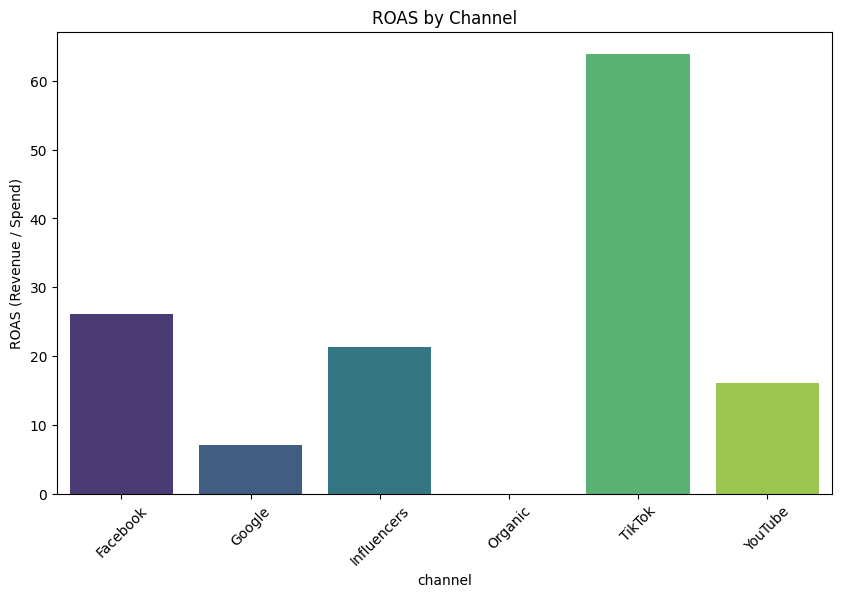

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    x=channel_perf.index,
    y=channel_perf["ROAS"],
    palette="viridis"
)
plt.title("ROAS by Channel")
plt.ylabel("ROAS (Revenue / Spend)")
plt.xticks(rotation=45)
plt.savefig("ROAS_by_Channel.png", dpi=200, bbox_inches="tight")
plt.show()


C:\Users\Ilaya\AppData\Local\Temp\ipykernel_14992\2849450980.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


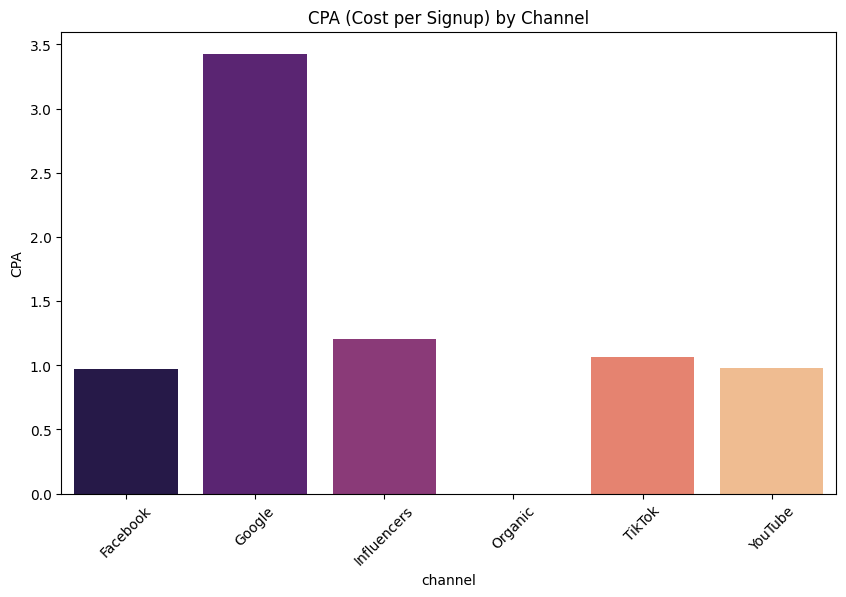

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=channel_perf.index,
    y=channel_perf["CPA"],
    palette="magma"
)
plt.title("CPA (Cost per Signup) by Channel")
plt.ylabel("CPA")
plt.xticks(rotation=45)
plt.savefig("Cost_per_Signup.png", dpi=200, bbox_inches="tight")

plt.show()


C:\Users\Ilaya\AppData\Local\Temp\ipykernel_14992\1150230751.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


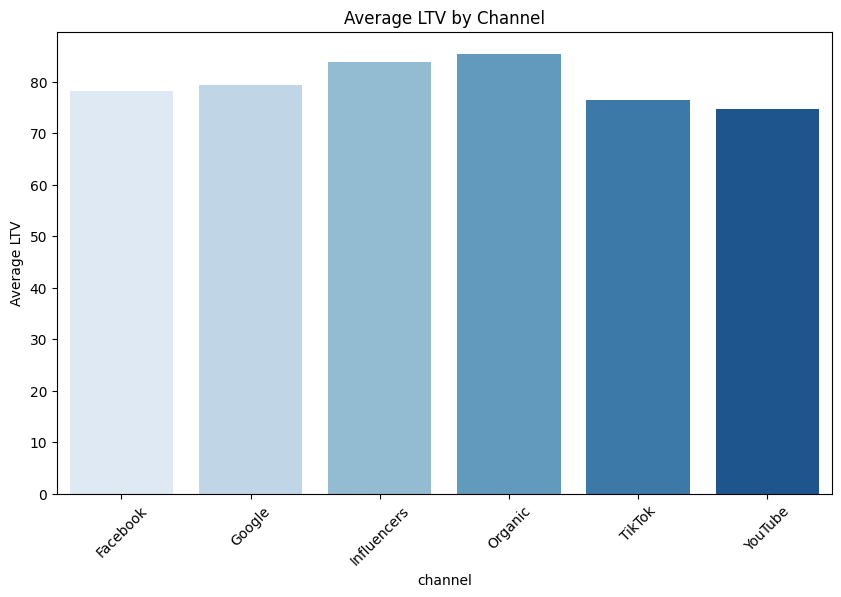

In [8]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=user_channel_perf.index,
    y=user_channel_perf["avg_ltv"],
    palette="Blues"
)
plt.title("Average LTV by Channel")
plt.ylabel("Average LTV")
plt.xticks(rotation=45)
plt.savefig("avg_ltv_by_channel.png", dpi=200, bbox_inches="tight")
plt.show()
